In [1]:
# ==========================
# STEP 1: Environment Setup & Imports
# ==========================

# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image handling
from PIL import Image
from pathlib import Path

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models, optimizers, callbacks

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Display settings
plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Test GPU availability in WSL
print("✅ All libraries imported successfully.")
print("TensorFlow version:", tf.__version__)
print("Num GPUs available:", len(tf.config.list_physical_devices('GPU')))


2025-10-10 20:02:49.405533: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-10 20:02:49.405608: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-10 20:02:49.408011: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-10 20:02:49.605630: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-10 20:02:50.949351: W tensorflow/compiler/

✅ All libraries imported successfully.
TensorFlow version: 2.14.0
Num GPUs available: 1


2025-10-10 20:02:52.174371: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-10 20:02:52.538279: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-10 20:02:52.538430: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


✅ Image folder found at: /mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_images
✅ Metadata file found at: /mnt/k/I.T/PROJECTS/Skin Disease Detection/data/HAM10000_metadata.csv
Metadata loaded successfully with shape: (10015, 7)
✅ Total valid images after filtering non-image files: 10015

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


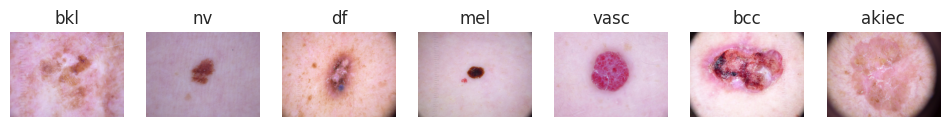

In [2]:
# ==========================
# STEP 2: Dataset Loading & Metadata Linking
# ==========================

# Paths (WSL-compatible)
BASE_DIR = Path("/mnt/k/I.T/PROJECTS/Skin Disease Detection/data")
IMAGE_DIR = BASE_DIR / "HAM10000_images"
METADATA_PATH = BASE_DIR / "HAM10000_metadata.csv"

# --- 1️⃣ Sanity checks ---
if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"Image directory not found: {IMAGE_DIR}")
if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Metadata CSV not found: {METADATA_PATH}")

print(f"✅ Image folder found at: {IMAGE_DIR}")
print(f"✅ Metadata file found at: {METADATA_PATH}")

# --- 2️⃣ Load metadata ---
metadata = pd.read_csv(METADATA_PATH)
print(f"Metadata loaded successfully with shape: {metadata.shape}")

# --- 3️⃣ Add image file paths ---
valid_extensions = ['.jpg', '.jpeg', '.png']
metadata['image_path'] = metadata['image_id'].apply(lambda x: IMAGE_DIR / f"{x}.jpg")
metadata = metadata[metadata['image_path'].apply(lambda x: x.exists() and x.suffix.lower() in valid_extensions)].reset_index(drop=True)

print(f"✅ Total valid images after filtering non-image files: {len(metadata)}")

# --- 4️⃣ Quick class distribution ---
print("\nClass distribution:")
print(metadata['dx'].value_counts())

# --- 5️⃣ Visualize some sample images ---
import matplotlib.pyplot as plt

sample_df = metadata.groupby('dx').head(1)  # 1 sample per class
plt.figure(figsize=(12,6))
for i, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.image_path)
    plt.subplot(1, len(sample_df), i)
    plt.imshow(img)
    plt.title(row.dx)
    plt.axis('off')
plt.show()


In [3]:
# ==========================
# STEP 3: Train–Validation–Test Split
# ==========================

from sklearn.model_selection import GroupShuffleSplit

# Define train + temp split first
train_ratio = 0.7
val_ratio = 0.15  # will split remaining 30% into val/test
test_ratio = 0.15

# Groups: lesion_id to avoid leakage
groups = metadata['lesion_id']

# First split: Train and Temp (val+test)
gss = GroupShuffleSplit(n_splits=1, train_size=train_ratio, random_state=42)
train_idx, temp_idx = next(gss.split(metadata, groups=groups))

train_df = metadata.iloc[train_idx].reset_index(drop=True)
temp_df = metadata.iloc[temp_idx].reset_index(drop=True)

# Second split: Temp into Validation and Test
temp_groups = temp_df['lesion_id']
val_size = val_ratio / (val_ratio + test_ratio)  # proportion within temp

gss_temp = GroupShuffleSplit(n_splits=1, train_size=val_size, random_state=42)
val_idx, test_idx = next(gss_temp.split(temp_df, groups=temp_groups))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

# Summary
print(f"✅ Train samples: {len(train_df)}")
print(f"✅ Validation samples: {len(val_df)}")
print(f"✅ Test samples: {len(test_df)}")


✅ Train samples: 7002
✅ Validation samples: 1519
✅ Test samples: 1494


In [5]:
# ==========================
# STEP 4: Preprocessing & Augmentation
# ==========================

# Image size for EfficientNetB0
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Compute class weights for imbalance handling
le = LabelEncoder()
train_labels_encoded = le.fit_transform(train_df['dx'])
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_encoded),
    y=train_labels_encoded
)
class_weights_dict = dict(enumerate(class_weights))
print("✅ Class weights:", class_weights_dict)

# ------------------------
# ImageDataGenerator setup
# ------------------------

# Training generator with real-time augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # EfficientNet preprocessing
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

# Validation & Test generator (no augmentation)
val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Convert Path objects to strings for ImageDataGenerator
train_df['image_path'] = train_df['image_path'].astype(str)
val_df['image_path'] = val_df['image_path'].astype(str)
test_df['image_path'] = test_df['image_path'].astype(str)


# ------------------------
# Flow from dataframe
# ------------------------
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


✅ Class weights: {0: 4.832298136645963, 1: 2.625421822272216, 2: 1.3499132446500868, 3: 11.23916532905297, 4: 1.2990723562152133, 5: 0.21201477623690426, 6: 10.419642857142858}
Found 7002 validated image filenames belonging to 7 classes.
Found 1519 validated image filenames belonging to 7 classes.
Found 1494 validated image filenames belonging to 7 classes.


In [10]:
# ==========================
# STEP 5: Model Building (EfficientNetB0) - Corrected
# ==========================

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models, optimizers, callbacks

# ✅ Get number of classes from LabelEncoder
NUM_CLASSES = len(le.classes_)
print("Number of classes:", NUM_CLASSES)

# Load pretrained EfficientNetB0 base (exclude top)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # freeze base for initial training

# Build the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Number of classes: 7


2025-10-10 20:21:37.572825: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-10 20:21:37.572963: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-10 20:21:37.573026: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-10 20:21:40.214280: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-10-10 20:21:40.214539: I tensorflow/compile

16705208/16705208 [==============================] - 4s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                         

In [ ]:
# ==========================
# STEP 6: Model Training
# ==========================

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# ------------------------
# Callbacks
# ------------------------
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# ------------------------
# Train the model
# ------------------------
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict,  # handle HAM10000 imbalance
    callbacks=[early_stop, model_checkpoint, reduce_lr],
    verbose=1
)


Epoch 1/30


2025-10-10 20:23:31.791030: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907
2025-10-10 20:23:36.771283: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x78d3f03169f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-10 20:23:36.771362: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-10-10 20:23:36.786519: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-10 20:23:37.032898: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


219/219 [==============================] - ETA: 0s - loss: 1.6326 - accuracy: 0.4019
Epoch 1: val_accuracy improved from -inf to 0.44437, saving model to best_model.h5


/home/krish/skinvision-env/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


219/219 [==============================] - 225s 983ms/step - loss: 1.6326 - accuracy: 0.4019 - val_loss: 1.4208 - val_accuracy: 0.4444 - lr: 0.0010
Epoch 2/30
219/219 [==============================] - ETA: 0s - loss: 1.3213 - accuracy: 0.4909
Epoch 2: val_accuracy improved from 0.44437 to 0.52864, saving model to best_model.h5
219/219 [==============================] - 129s 589ms/step - loss: 1.3213 - accuracy: 0.4909 - val_loss: 1.2403 - val_accuracy: 0.5286 - lr: 0.0010
Epoch 3/30
219/219 [==============================] - ETA: 0s - loss: 1.2439 - accuracy: 0.5156
Epoch 3: val_accuracy improved from 0.52864 to 0.60434, saving model to best_model.h5
219/219 [==============================] - 130s 592ms/step - loss: 1.2439 - accuracy: 0.5156 - val_loss: 1.0439 - val_accuracy: 0.6043 - lr: 0.0010
Epoch 4/30
219/219 [==============================] - ETA: 0s - loss: 1.1539 - accuracy: 0.5464
Epoch 4: val_accuracy did not improve from 0.60434
219/219 [==============================] - 12

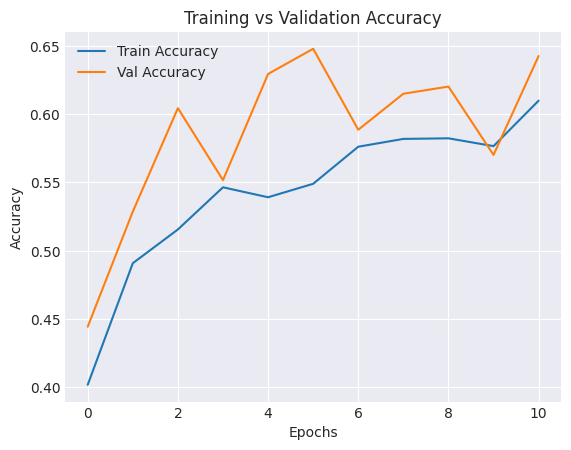

In [12]:
# Plot training history
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


47/47 [==============================] - 35s 722ms/step - loss: 0.9303 - accuracy: 0.6499
Test Accuracy: 0.6499
Test Loss: 0.9303
47/47 [==============================] - 16s 325ms/step
Classification Report:
              precision    recall  f1-score   support

       akiec       0.45      0.48      0.47        63
         bcc       0.44      0.54      0.48        68
         bkl       0.35      0.55      0.42       152
          df       0.10      0.57      0.17         7
         mel       0.37      0.43      0.40       187
          nv       0.93      0.72      0.81       996
        vasc       0.26      0.90      0.40        21

    accuracy                           0.65      1494
   macro avg       0.41      0.60      0.45      1494
weighted avg       0.75      0.65      0.68      1494



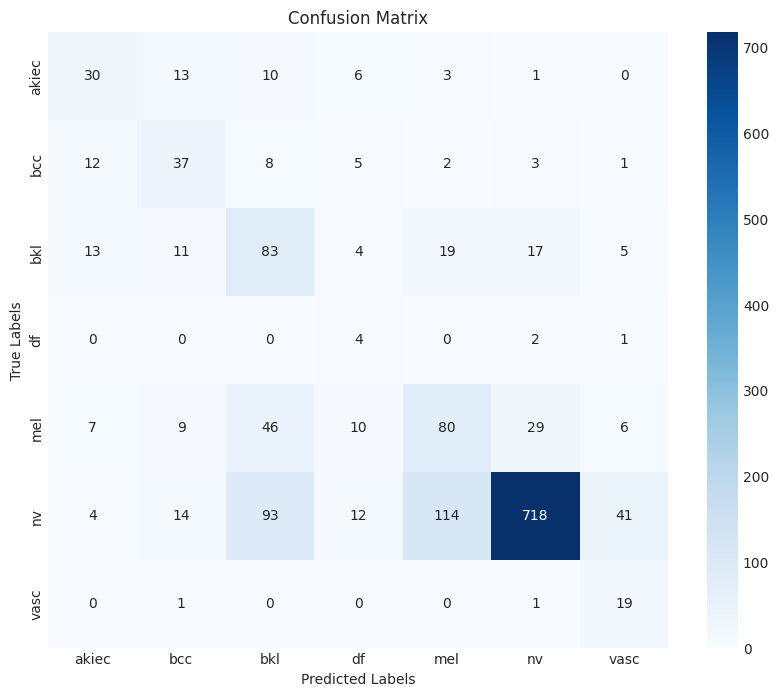

In [13]:
# ==========================
# STEP 7: Evaluation & Confusion Matrix
# ==========================

from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Load the best model
best_model = load_model("best_model.h5")

# 2️⃣ Evaluate on test set
test_loss, test_acc = best_model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# 3️⃣ Predict labels for test set
test_generator.reset()  # ensure predictions start from first batch
pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes  # true labels

# 4️⃣ Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# 5️⃣ Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# ==========================
# STEP 8: Fine-Tuning & Data Augmentation (Corrected)
# ==========================

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import mixed_precision
from sklearn.utils import resample

# -------------------------
# 1️⃣ Mixed precision for RTX 3050
# -------------------------
mixed_precision.set_global_policy('mixed_float16')

# -------------------------
# 2️⃣ Unfreeze top layers of EfficientNetB0 for fine-tuning
# -------------------------
base_model.trainable = True
for layer in base_model.layers[:-60]:  # freeze first layers, train last 60
    layer.trainable = False

print("Number of trainable layers:", sum([l.trainable for l in base_model.layers]))

# -------------------------
# 3️⃣ Oversample minority classes in train_df
# -------------------------
train_df_list = []
max_count = train_df['dx'].value_counts().max()  # largest class count
for cls in train_df['dx'].unique():
    cls_df = train_df[train_df['dx'] == cls]
    cls_upsampled = resample(cls_df, replace=True, n_samples=max_count, random_state=SEED)
    train_df_list.append(cls_upsampled)

train_df_balanced = pd.concat(train_df_list).sample(frac=1, random_state=SEED)  # shuffle

# -------------------------
# 4️⃣ Data augmentation
# -------------------------
train_datagen_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

train_generator_aug = train_datagen_aug.flow_from_dataframe(
    dataframe=train_df_balanced,
    x_col='image_path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

# -------------------------
# 5️⃣ Callbacks
# -------------------------
fine_tune_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('best_model_finetuned.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# -------------------------
# 6️⃣ Compile model with lower LR for fine-tuning
# -------------------------
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# -------------------------
# 7️⃣ Fine-tune the model
# -------------------------
history_finetune = model.fit(
    train_generator_aug,
    validation_data=val_generator,
    epochs=20,  # 10-20 epochs is usually enough
    callbacks=fine_tune_callbacks
)


Number of trainable layers: 50
Found 33026 validated image filenames belonging to 7 classes.
Epoch 1/20


2025-10-10 21:51:51.101010: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1033/1033 [==============================] - ETA: 0s - loss: 0.6845 - accuracy: 0.7480
Epoch 1: val_accuracy improved from -inf to 0.65438, saving model to best_model_finetuned.h5


/home/krish/skinvision-env/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1033/1033 [==============================] - 525s 500ms/step - loss: 0.6845 - accuracy: 0.7480 - val_loss: 0.9283 - val_accuracy: 0.6544 - lr: 1.0000e-04
Epoch 2/20
1033/1033 [==============================] - ETA: 0s - loss: 0.3651 - accuracy: 0.8682
Epoch 2: val_accuracy improved from 0.65438 to 0.71165, saving model to best_model_finetuned.h5
1033/1033 [==============================] - 510s 493ms/step - loss: 0.3651 - accuracy: 0.8682 - val_loss: 0.9087 - val_accuracy: 0.7117 - lr: 1.0000e-04
Epoch 3/20
1033/1033 [==============================] - ETA: 0s - loss: 0.2623 - accuracy: 0.9057
Epoch 3: val_accuracy did not improve from 0.71165
1033/1033 [==============================] - 505s 488ms/step - loss: 0.2623 - accuracy: 0.9057 - val_loss: 1.0699 - val_accuracy: 0.6860 - lr: 1.0000e-04
Epoch 4/20
1033/1033 [==============================] - ETA: 0s - loss: 0.2003 - accuracy: 0.9285
Epoch 4: val_accuracy did not improve from 0.71165
1033/1033 [==============================] - 5

In [1]:
#1) Load best model, evaluate test, print classification report + confusion matrix

from tensorflow.keras.models import load_model
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# load best fine-tuned model (restored weights from epoch 10)
best = load_model("best_model_finetuned.h5")

# evaluate
test_loss, test_acc = best.evaluate(test_generator, verbose=1)
print("Test acc:", test_acc, "Test loss:", test_loss)

# predict and metrics
test_generator.reset()
preds = best.predict(test_generator, verbose=1)
y_pred = preds.argmax(axis=1)
y_true = test_generator.classes
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('True'); plt.show()


2025-10-11 11:12:58.518025: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-11 11:12:58.518161: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-11 11:12:58.521597: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-11 11:12:58.800674: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-11 11:13:00.998348: W tensorflow/compiler/

NameError: name 'test_generator' is not defined

Found 1527 validated image filenames belonging to 7 classes.


2025-10-11 11:16:15.438946: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8907


48/48 [==============================] - 39s 686ms/step - loss: 1.1758 - accuracy: 0.7282
Test Accuracy: 0.7282  |  Test Loss: 1.1758
48/48 [==============================] - 18s 351ms/step
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
              precision    recall  f1-score   support

       akiec       0.73      0.17      0.27        48
         bcc       0.56      0.58      0.57        66
         bkl       0.45      0.81      0.58       172
          df       0.33      0.50      0.40        10
         mel       0.42      0.63      0.51       186
          nv       0.95      0.77      0.85      1016
        vasc       0.82      0.79      0.81        29

    accuracy                           0.73      1527
   macro avg       0.61      0.61      0.57      1527
weighted avg       0.80      0.73      0.74      1527



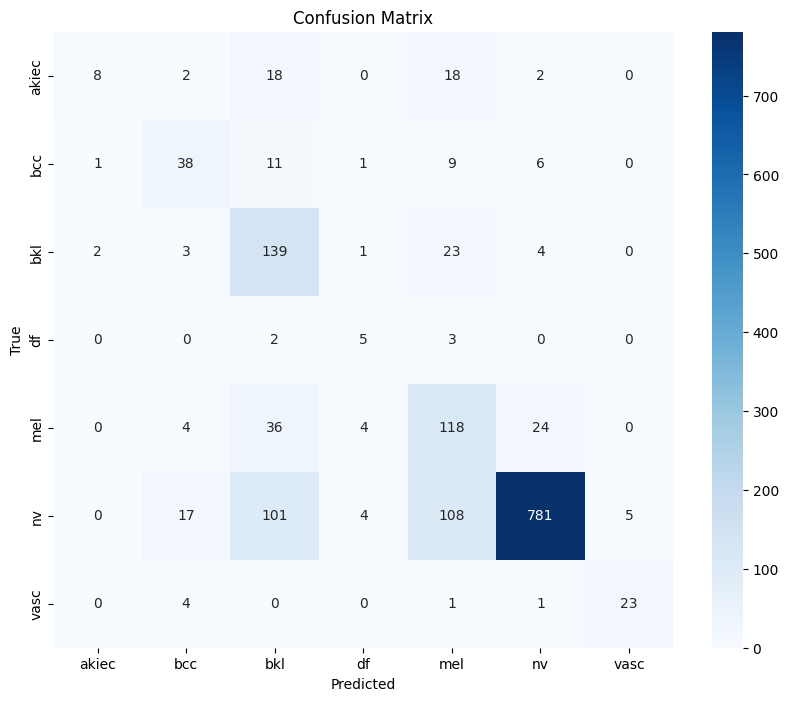

In [2]:
# ---------- Recreate test_generator and evaluate best model ----------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# 1) Settings - make sure these match what you used earlier
BASE_DIR = "/mnt/k/I.T/PROJECTS/Skin Disease Detection/data"
IMAGE_DIR = BASE_DIR + "/HAM10000_images"
METADATA_PATH = BASE_DIR + "/HAM10000_metadata.csv"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# 2) Load metadata and ensure image_path column (strings)
df = pd.read_csv(METADATA_PATH)
df['image_path'] = df['image_id'].astype(str) + ".jpg"
df['image_path'] = df['image_path'].apply(lambda x: IMAGE_DIR + "/" + x)

# If you already have test_df created earlier, you can skip building from metadata
# and instead use the existing test_df from your session. Otherwise, rebuild splits
# (use the same split method you used before). Below I'll assume you have test_df CSV:
# Uncomment if you saved test split previously:
# test_df = pd.read_csv("test_df.csv")

# If `test_df` isn't saved, create it quickly (group split recommended earlier):
# Here is a quick reconstruct: (only use if you didn't save splits before)
# NOTE: This is a quick stratified split and may NOT match exactly previous split.
from sklearn.model_selection import GroupShuffleSplit
if 'test_df' not in globals():
    metadata = df.copy()
    # ensure columns used below exist in your metadata (lesion_id, dx)
    # If you didn't keep lesion_id, fallback to stratified by dx (less ideal)
    if 'lesion_id' in metadata.columns:
        gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
        _, test_idx = next(gss.split(metadata, groups=metadata['lesion_id']))
        test_df = metadata.iloc[test_idx].reset_index(drop=True)
    else:
        # fallback: stratified by dx
        from sklearn.model_selection import train_test_split
        _, test_df = train_test_split(metadata, test_size=0.15, stratify=metadata['dx'], random_state=SEED)

# 3) Make sure paths are strings and labels are strings
test_df['image_path'] = test_df['image_path'].astype(str)
test_df['dx'] = test_df['dx'].astype(str)

# 4) Create ImageDataGenerator for test (no augmentation)
test_datagen = ImageDataGenerator(preprocessing_function=__import__('tensorflow').keras.applications.efficientnet.preprocess_input)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# 5) Load the best model (fine-tuned)
best_model = load_model("best_model_finetuned.h5")   # or best_model_finetuned.keras

# 6) Evaluate + predictions
test_loss, test_acc = best_model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}  |  Test Loss: {test_loss:.4f}")

test_generator.reset()
pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

# 7) If you used LabelEncoder earlier, load or rebuild mapping:
# If you have `le` in memory, use le.classes_. Otherwise make mapping from generator.
class_names = list(test_generator.class_indices.keys())  # order matches indices
print("Classes:", class_names)

# 8) Classification report and confusion matrix
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Confusion Matrix')
plt.show()
